<a href="https://colab.research.google.com/github/192512041simats-hari/IOE-AND-AI-SYSTEM/blob/main/IOE%20EXP_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

===== IoT Smart Building Sensor Dataset =====

 Hour  Room_Temp(C)  Occupancy(people)  CO2_Level(ppm)  Outdoor_Temp(C)  HVAC_Status
    0         22.05                  5           350.0               34            0
    1         20.91                  9           350.0               22            0
    2         21.79                  7           350.0               18            0
    3         23.08                 15           350.0               20            0
    4         21.51                 14           350.0               20            0
    5         22.31                 18           456.3               24            0
    6         25.50                 20           532.5               30            1
    7         25.68                 33           588.2               22            1
    8         25.44                 28           575.1               18            1
    9         27.89                 26           649.7               24            1
   10         27.8

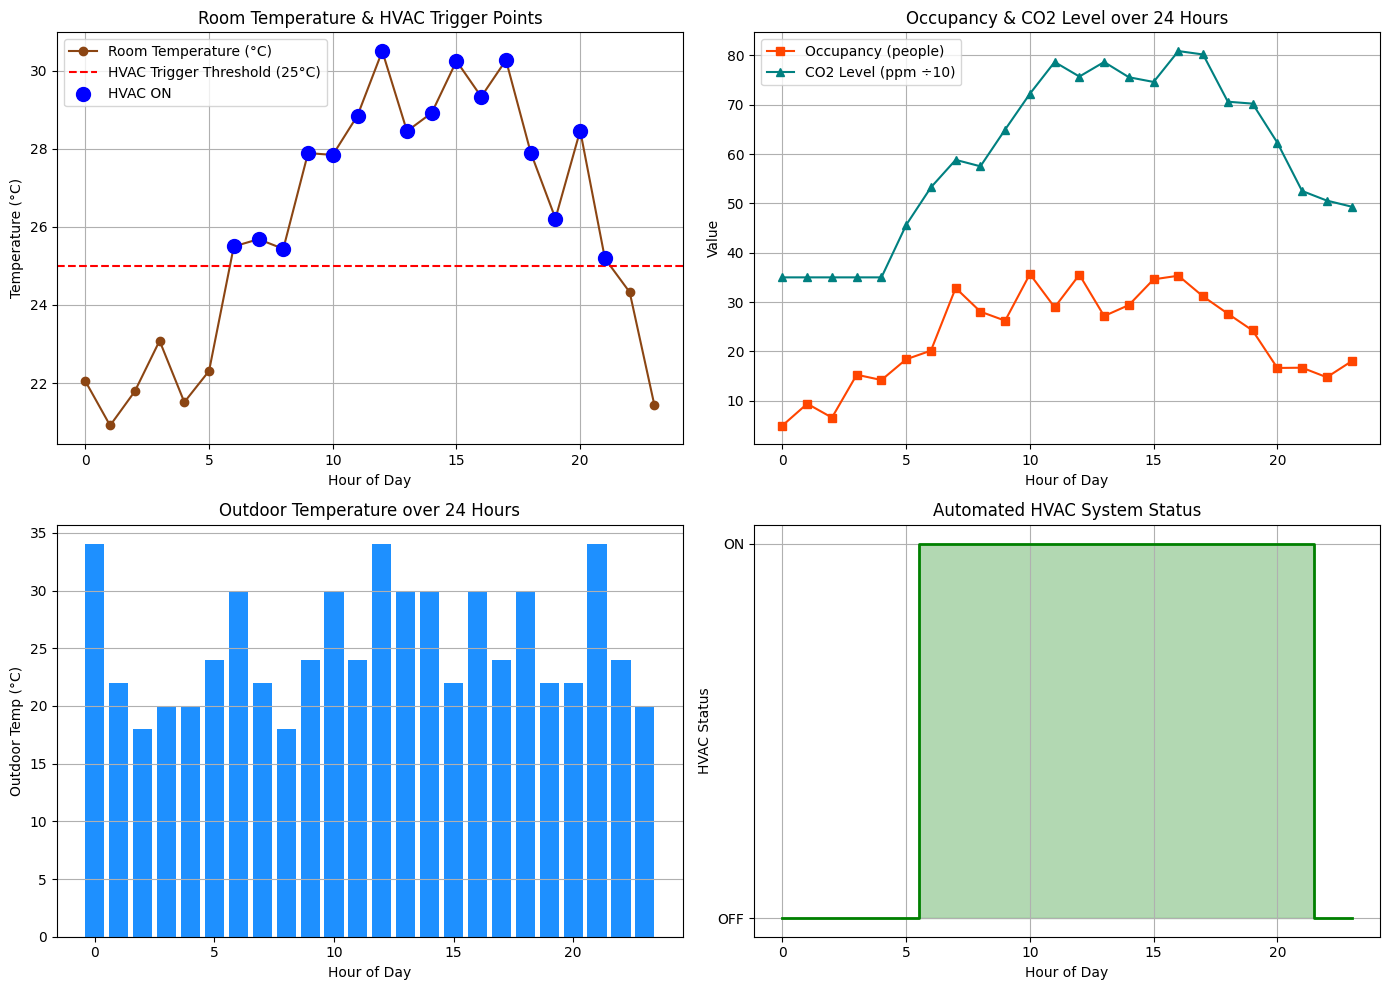


Dataset saved as 'smart_building_hvac_dataset.csv'


In [1]:

# IoT-Based Smart Building HVAC Automated Climate Control System
# --------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Simulate IoT Sensor Dataset (24-hour monitoring, hourly readings)
np.random.seed(42)
hours = np.arange(0, 24)

# Simulated sensor readings
room_temp     = np.clip(26 + 5*np.sin((hours-8)/4) + np.random.normal(0, 1.2, 24), 15, 40)   # °C
occupancy     = np.clip(20 + 15*np.cos((hours-13)/5) + np.random.normal(0, 4, 24), 0, 50)     # people count
co2_level     = np.clip(500 + 300*np.cos((hours-14)/5) + np.random.normal(0, 40, 24), 350, 1500)  # ppm
outdoor_temp  = np.random.choice([18, 20, 22, 24, 30, 34], size=24)                            # °C

# Step 2: Automated HVAC Decision Logic
# Rule: HVAC ON if room temp > 25°C AND occupancy > 5 people AND CO2 < 1200 ppm (not already ventilating heavily)
TEMP_THRESHOLD = 25
hvac_status = []
for temp, occ, co2 in zip(room_temp, occupancy, co2_level):
    if temp > TEMP_THRESHOLD and occ > 5 and co2 < 1200:
        hvac_status.append(1)   # HVAC ON
    else:
        hvac_status.append(0)   # HVAC OFF

df = pd.DataFrame({
    'Hour': hours,
    'Room_Temp(C)': room_temp.round(2),
    'Occupancy(people)': occupancy.round(0).astype(int),
    'CO2_Level(ppm)': co2_level.round(1),
    'Outdoor_Temp(C)': outdoor_temp,
    'HVAC_Status': hvac_status
})

print("===== IoT Smart Building Sensor Dataset =====\n")
print(df.to_string(index=False))

hvac_run_hours = df['HVAC_Status'].sum()
avg_room_temp = df['Room_Temp(C)'].mean()
print(f"\nTotal HVAC running hours (ON): {hvac_run_hours} hrs")
print(f"Average room temperature over 24h : {avg_room_temp:.2f}°C")

# Step 3: Visualization
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# (a) Room temperature with threshold and HVAC-on markers
axs[0, 0].plot(hours, room_temp, marker='o', color='saddlebrown', label='Room Temperature (°C)')
axs[0, 0].axhline(TEMP_THRESHOLD, color='red', linestyle='--', label='HVAC Trigger Threshold (25°C)')
hvac_on_hours = df[df['HVAC_Status'] == 1]['Hour']
hvac_on_temp = df[df['HVAC_Status'] == 1]['Room_Temp(C)']
axs[0, 0].scatter(hvac_on_hours, hvac_on_temp, color='blue', s=100, zorder=5, label='HVAC ON')
axs[0, 0].set_title('Room Temperature & HVAC Trigger Points')
axs[0, 0].set_xlabel('Hour of Day')
axs[0, 0].set_ylabel('Temperature (°C)')
axs[0, 0].legend()
axs[0, 0].grid(True)

# (b) Occupancy and CO2 trends
axs[0, 1].plot(hours, occupancy, marker='s', color='orangered', label='Occupancy (people)')
axs[0, 1].plot(hours, co2_level/10, marker='^', color='teal', label='CO2 Level (ppm ÷10)')
axs[0, 1].set_title('Occupancy & CO2 Level over 24 Hours')
axs[0, 1].set_xlabel('Hour of Day')
axs[0, 1].set_ylabel('Value')
axs[0, 1].legend()
axs[0, 1].grid(True)

# (c) Outdoor temperature bar chart
axs[1, 0].bar(hours, outdoor_temp, color='dodgerblue')
axs[1, 0].set_title('Outdoor Temperature over 24 Hours')
axs[1, 0].set_xlabel('Hour of Day')
axs[1, 0].set_ylabel('Outdoor Temp (°C)')
axs[1, 0].grid(True, axis='y')

# (d) HVAC ON/OFF status timeline
axs[1, 1].step(hours, hvac_status, where='mid', color='green', linewidth=2)
axs[1, 1].fill_between(hours, hvac_status, step='mid', alpha=0.3, color='green')
axs[1, 1].set_title('Automated HVAC System Status')
axs[1, 1].set_xlabel('Hour of Day')
axs[1, 1].set_ylabel('HVAC Status')
axs[1, 1].set_yticks([0, 1])
axs[1, 1].set_yticklabels(['OFF', 'ON'])
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Step 4: Save dataset as CSV (optional download in Colab)
df.to_csv('smart_building_hvac_dataset.csv', index=False)
print("\nDataset saved as 'smart_building_hvac_dataset.csv'")